## Imports

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

## Load MNIST dataset

In [2]:
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()
train_images = train_images.astype('float32') / 255
test_images = test_images.astype('float32') / 255

In [3]:
print('Number of images in the training dataset:', train_images.shape[0])
print('Number of images in the testing dataset:', test_images.shape[0])

Number of images in the training dataset: 60000
Number of images in the testing dataset: 10000


In [4]:
print(f"Shape of the images in the training dataset: {train_images[0].shape}")

Shape of the images in the training dataset: (28, 28)


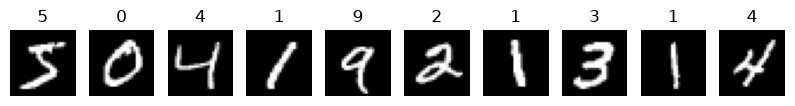

In [5]:
fig, axes = plt.subplots(1, 10, figsize=(10, 10))
for i in range(10):
    axes[i].imshow(train_images[i].reshape(28, 28), cmap='gray')
    axes[i].set_title(train_labels[i])
    axes[i].axis('off')
plt.show()

## Define neural network

In [6]:
model = models.Sequential([
    layers.Flatten(input_shape=(28, 28, 1)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

C:\Users\Nelith\Downloads\optical-character-recognition\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


## Train the model

In [7]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(
    train_images, 
    train_labels, 
    epochs=5
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 850us/step - accuracy: 0.9307 - loss: 0.2384
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 827us/step - accuracy: 0.9703 - loss: 0.0998
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 817us/step - accuracy: 0.9790 - loss: 0.0689
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 815us/step - accuracy: 0.9852 - loss: 0.0495
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 819us/step - accuracy: 0.9880 - loss: 0.0392


In [8]:
def view_classify(image, probabilities):
    fig, (ax1, ax2) = plt.subplots(figsize=(6,9), ncols=2)
    ax1.imshow(image)
    ax1.axis('off')
    ax2.barh(np.arange(10), probabilities)
    ax2.set_aspect(0.1)
    ax2.set_yticks(np.arange(10))
    ax2.set_yticklabels(np.arange(10))
    ax2.set_title('Class Probability')
    ax2.set_xlim(0, 1.1)
    plt.tight_layout()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


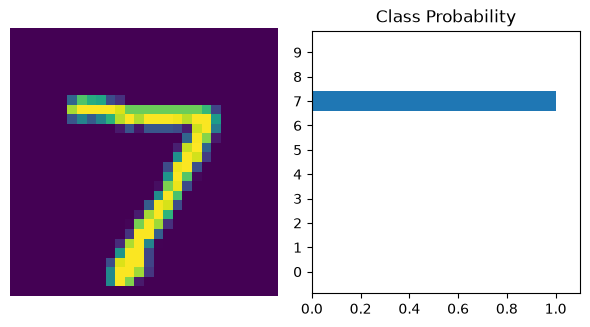

In [9]:
image, label = test_images[0], test_labels[0]
probabilities = model.predict(image.reshape(1, 28, 28, 1))
view_classify(image,  probabilities[0])

## Test the model

In [10]:
test_loss, test_accuracy = model.evaluate(test_images, test_labels)
print(f'Accuracy of the neural network on the {test_images.shape[0]} test images: {test_accuracy * 100:.2f}%')

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 805us/step - accuracy: 0.9770 - loss: 0.0829
Accuracy of the neural network on the 10000 test images: 97.70%


## Custom test 1

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Predicted digit: 6
Confidence: 99.97458


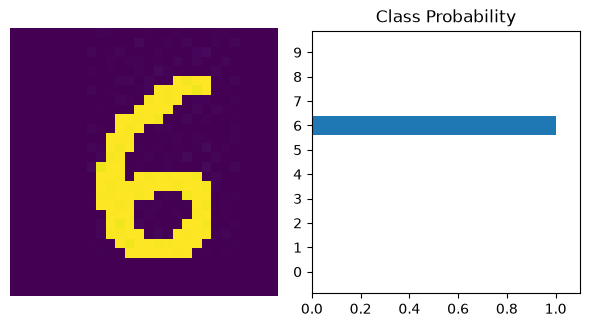

In [15]:
# Load image
img1 = Image.open("img1.jpg").convert("L")

# Resize to MNIST dimensions
img1 = img1.resize((28, 28))

# Convert to numpy array
img1 = np.array(img1)
img1 = 255 - img1

# Normalize pixel values to 0-1
img1 = img1.astype("float32") / 255.0

probabilities = model.predict(img1.reshape(1, 28, 28, 1))

print("Predicted digit:", np.argmax(probabilities[0]))
print("Confidence:", np.max(probabilities[0]) * 100)

view_classify(img1,  probabilities[0])

## Custom test 2

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Predicted digit: 7
Confidence: 99.98633


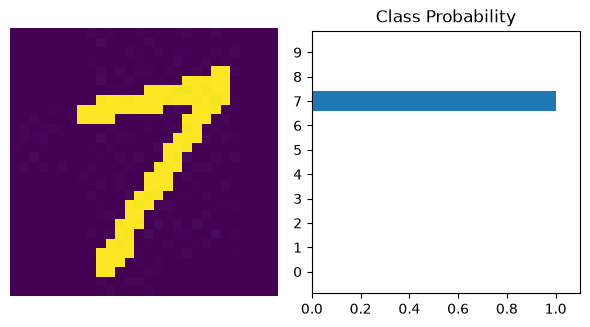

In [17]:
# Load image
img2 = Image.open("img2.jpg").convert("L")

# Resize to MNIST dimensions
img2 = img2.resize((28, 28))

# Convert to numpy array
img2 = np.array(img2)
img2 = 255 - img2

# Normalize pixel values to 0-1
img2 = img2.astype("float32") / 255.0

probabilities = model.predict(img2.reshape(1, 28, 28, 1))

print("Predicted digit:", np.argmax(probabilities[0]))
print("Confidence:", np.max(probabilities[0]) * 100)

view_classify(img2,  probabilities[0])

## Custom test 3

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Predicted digit: 2
Confidence: 70.0767


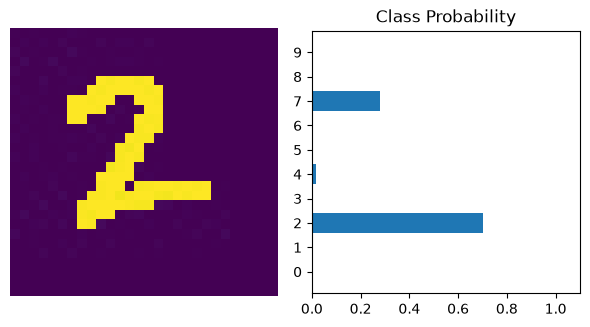

In [18]:
# Load image
img3 = Image.open("img3.jpg").convert("L")

# Resize to MNIST dimensions
img3 = img3.resize((28, 28))

# Convert to numpy array
img3 = np.array(img3)
img3 = 255 - img3

# Normalize pixel values to 0-1
img3 = img3.astype("float32") / 255.0

probabilities = model.predict(img3.reshape(1, 28, 28, 1))

print("Predicted digit:", np.argmax(probabilities[0]))
print("Confidence:", np.max(probabilities[0]) * 100)

view_classify(img3,  probabilities[0])